## Task 2: Hands-On Data Lab Implementation
Data Analyst Internship
Topics: environment setup, data inspection, cleaning, manipulation,
visualization, and basic analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# 1. Load the dataset
df = pd.read_csv("sales_data.csv")

In [3]:
# 2. Inspect the dataset
print("First five records:")
print(df.head())

First five records:
   Order_ID   Product     Category  Quantity  Revenue
0      1001    Laptop  Electronics         2   120000
1      1002     Mouse  Electronics         5     5000
2      1003     Chair    Furniture         3    15000
3      1004      Desk    Furniture         1    18000
4      1005  Keyboard  Electronics         4     8000


In [4]:
print("\nDataset shape:")
print(df.shape)


Dataset shape:
(10, 5)


In [5]:
print("\nDataset information:")
print(df.info())


Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Order_ID  10 non-null     int64 
 1   Product   10 non-null     object
 2   Category  10 non-null     object
 3   Quantity  10 non-null     int64 
 4   Revenue   10 non-null     int64 
dtypes: int64(3), object(2)
memory usage: 528.0+ bytes
None


In [6]:
print("\nDescriptive statistics:")
print(df.describe())


Descriptive statistics:
         Order_ID  Quantity        Revenue
count    10.00000  10.00000      10.000000
mean   1005.50000   2.90000   25600.000000
std       3.02765   1.66333   34010.455909
min    1001.00000   1.00000    5000.000000
25%    1003.25000   2.00000    9750.000000
50%    1005.50000   2.50000   15000.000000
75%    1007.75000   3.75000   22500.000000
max    1010.00000   6.00000  120000.000000


In [7]:
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
Order_ID    0
Product     0
Category    0
Quantity    0
Revenue     0
dtype: int64


In [8]:
print("\nDuplicate records:")
print(df.duplicated().sum())


Duplicate records:
0


In [9]:
# 3. Data cleaning and type conversion
df["Product"] = df["Product"].astype("string").str.strip()
df["Category"] = df["Category"].astype("string").str.strip().str.title()
df["Quantity"] = pd.to_numeric(df["Quantity"], errors="coerce")
df["Revenue"] = pd.to_numeric(df["Revenue"], errors="coerce")

In [10]:
# Remove duplicate rows
df = df.drop_duplicates()

In [11]:
# Keep valid business records
df = df[df["Quantity"] > 0]
df = df[df["Revenue"] >= 0]

In [12]:
# 4. Feature engineering
df["Average_Value"] = df["Revenue"] / df["Quantity"]

In [13]:
# 5. Data manipulation
high_value_orders = df[df["Revenue"] > 10000]
sorted_data = df.sort_values("Revenue", ascending=False)

category_summary = (
    df.groupby("Category", as_index=False)
      .agg(
          Total_Revenue=("Revenue", "sum"),
          Average_Revenue=("Revenue", "mean"),
          Total_Quantity=("Quantity", "sum")
      )
      .sort_values("Total_Revenue", ascending=False)
)

In [15]:
print("\nHigh-value orders:")
print(high_value_orders)


High-value orders:
   Order_ID     Product     Category  Quantity  Revenue  Average_Value
0      1001      Laptop  Electronics         2   120000        60000.0
2      1003       Chair    Furniture         3    15000         5000.0
3      1004        Desk    Furniture         1    18000        18000.0
5      1006     Monitor  Electronics         2    30000        15000.0
6      1007       Table    Furniture         2    24000        12000.0
7      1008  Headphones  Electronics         6    12000         2000.0
9      1010      Webcam  Electronics         3    15000         5000.0


In [16]:
print("\nSorted data:")
print(sorted_data)


Sorted data:
   Order_ID     Product     Category  Quantity  Revenue  Average_Value
0      1001      Laptop  Electronics         2   120000        60000.0
5      1006     Monitor  Electronics         2    30000        15000.0
6      1007       Table    Furniture         2    24000        12000.0
3      1004        Desk    Furniture         1    18000        18000.0
2      1003       Chair    Furniture         3    15000         5000.0
9      1010      Webcam  Electronics         3    15000         5000.0
7      1008  Headphones  Electronics         6    12000         2000.0
8      1009     Cabinet    Furniture         1     9000         9000.0
4      1005    Keyboard  Electronics         4     8000         2000.0
1      1002       Mouse  Electronics         5     5000         1000.0


In [17]:
print("\nCategory summary:")
print(category_summary)


Category summary:
      Category  Total_Revenue  Average_Revenue  Total_Quantity
0  Electronics         190000     31666.666667              22
1    Furniture          66000     16500.000000               7


In [18]:
# 6. Basic analysis
total_revenue = df["Revenue"].sum()
average_revenue = df["Revenue"].mean()
median_revenue = df["Revenue"].median()
total_quantity = df["Quantity"].sum()

In [19]:
print("\nBasic analysis results:")
print(f"Total revenue: {total_revenue:,.2f}")
print(f"Average revenue per order: {average_revenue:,.2f}")
print(f"Median revenue per order: {median_revenue:,.2f}")
print(f"Total quantity sold: {total_quantity}")


Basic analysis results:
Total revenue: 256,000.00
Average revenue per order: 25,600.00
Median revenue per order: 15,000.00
Total quantity sold: 29


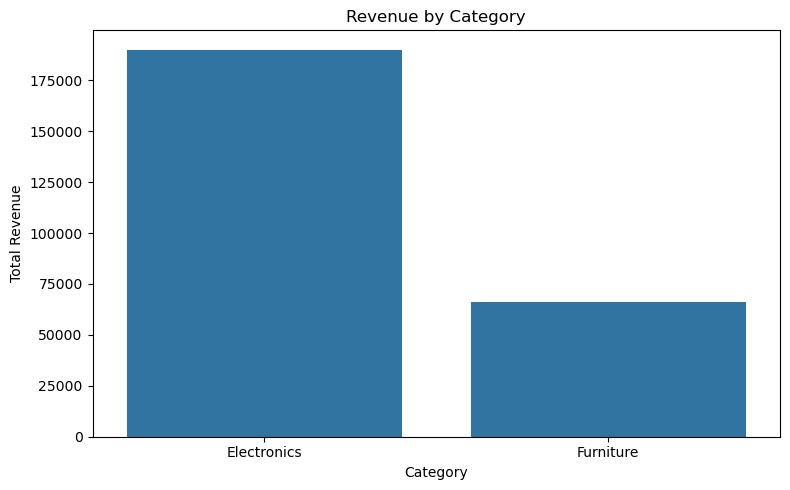

In [20]:
# 7. Visualization: revenue by category
plt.figure(figsize=(8, 5))
sns.barplot(data=category_summary, x="Category", y="Total_Revenue")
plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Total Revenue")
plt.tight_layout()
plt.show()

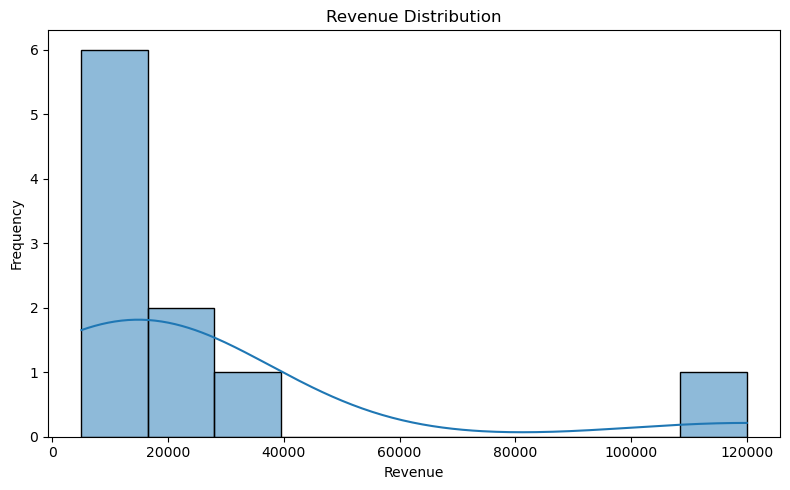

In [21]:
# 8. Visualization: revenue distribution
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Revenue", kde=True)
plt.title("Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

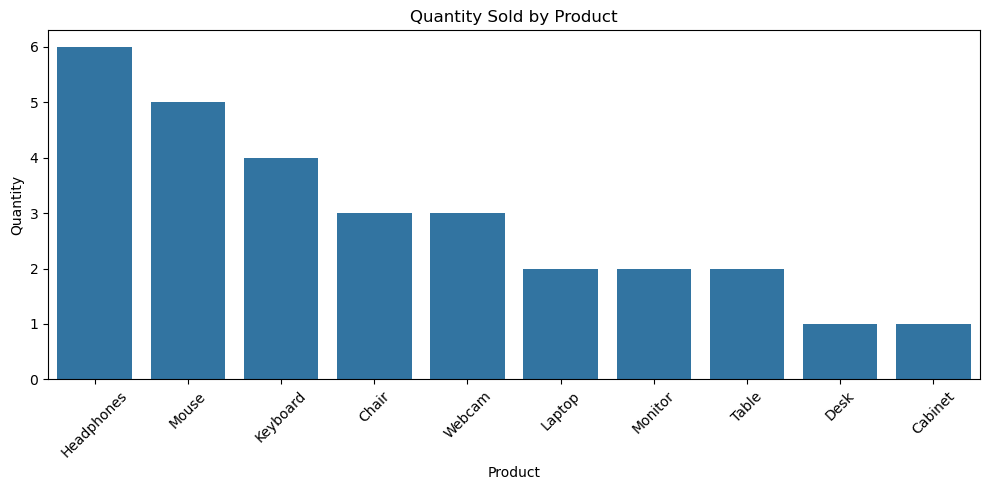

In [22]:
# 9. Visualization: quantity by product
product_summary = df.sort_values("Quantity", ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=product_summary, x="Product", y="Quantity")
plt.title("Quantity Sold by Product")
plt.xlabel("Product")
plt.ylabel("Quantity")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [23]:
# 10. Save cleaned data and summary
df.to_csv("cleaned_sales_data.csv", index=False)
category_summary.to_csv("category_summary.csv", index=False)

print("\nCleaned dataset and summary files saved successfully.")



Cleaned dataset and summary files saved successfully.
